# Convolutional Neural Network - Code

In diesem Notebook schauen wir uns das `Convolutional Neural Network` Modell am MNIST Datensatz an.
Wir verwenden dazu `tensorflow`, die Deep Learning Python Library von Google.

## Setup

Setup Code muss *nicht* verstanden werden.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

In [2]:
def plot_images(data, nrows=18, ncols=18):
    """
    Plot images with or without original data.
    :param data: Data to plot
    :param nrows: number of rows
    :param ncols: number of columns
    """
    data = data.reshape(data.shape[0], 8, 8)
    _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 16))
    for ax, image in zip(axes.flatten(), data):
        ax.set_axis_off()
        ax.imshow(image, cmap='gray')

In [3]:
def plot_history(history):
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [4]:
def plot_confusion_matrix(y_true: any, y_pred: any):
    """
        Takes true and predicted labels (arrays) as input. Based on this, calculates and plots a confusion matrix.
    """
    labels = np.unique(y_true)
    fig = plt.figure(figsize=(len(labels), len(labels)))
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true=y_true, y_pred=y_pred, labels=labels, normalize='all'),
        display_labels=labels
    ).plot(ax=fig.gca(), cmap="BuPu", xticks_rotation='vertical', include_values=True)
    plt.show()

## Datensatz - MNIST

MNIST Daten sind Schwarz-Weiss Bilder von den Zahlen von 0 bis 9.
Es sind insgesamt 1797 Bilder mit 8 * 8 Pixel (`X_data`). Zu jedem Bild haben wir ein Label, welche Zahl auf dem Bild abgebildet ist (`y_data`).

In [5]:
data = load_digits()  # Load MNIST data set
X_data, y_data = data.images, data.target

print(X_data.shape)
print(y_data.shape)

(1797, 8, 8)
(1797,)


Wir visualisieren hier ein paar MNIST-Bilder, um einen Eindruck der Daten zu erhalten.

MNIST examples from dataset


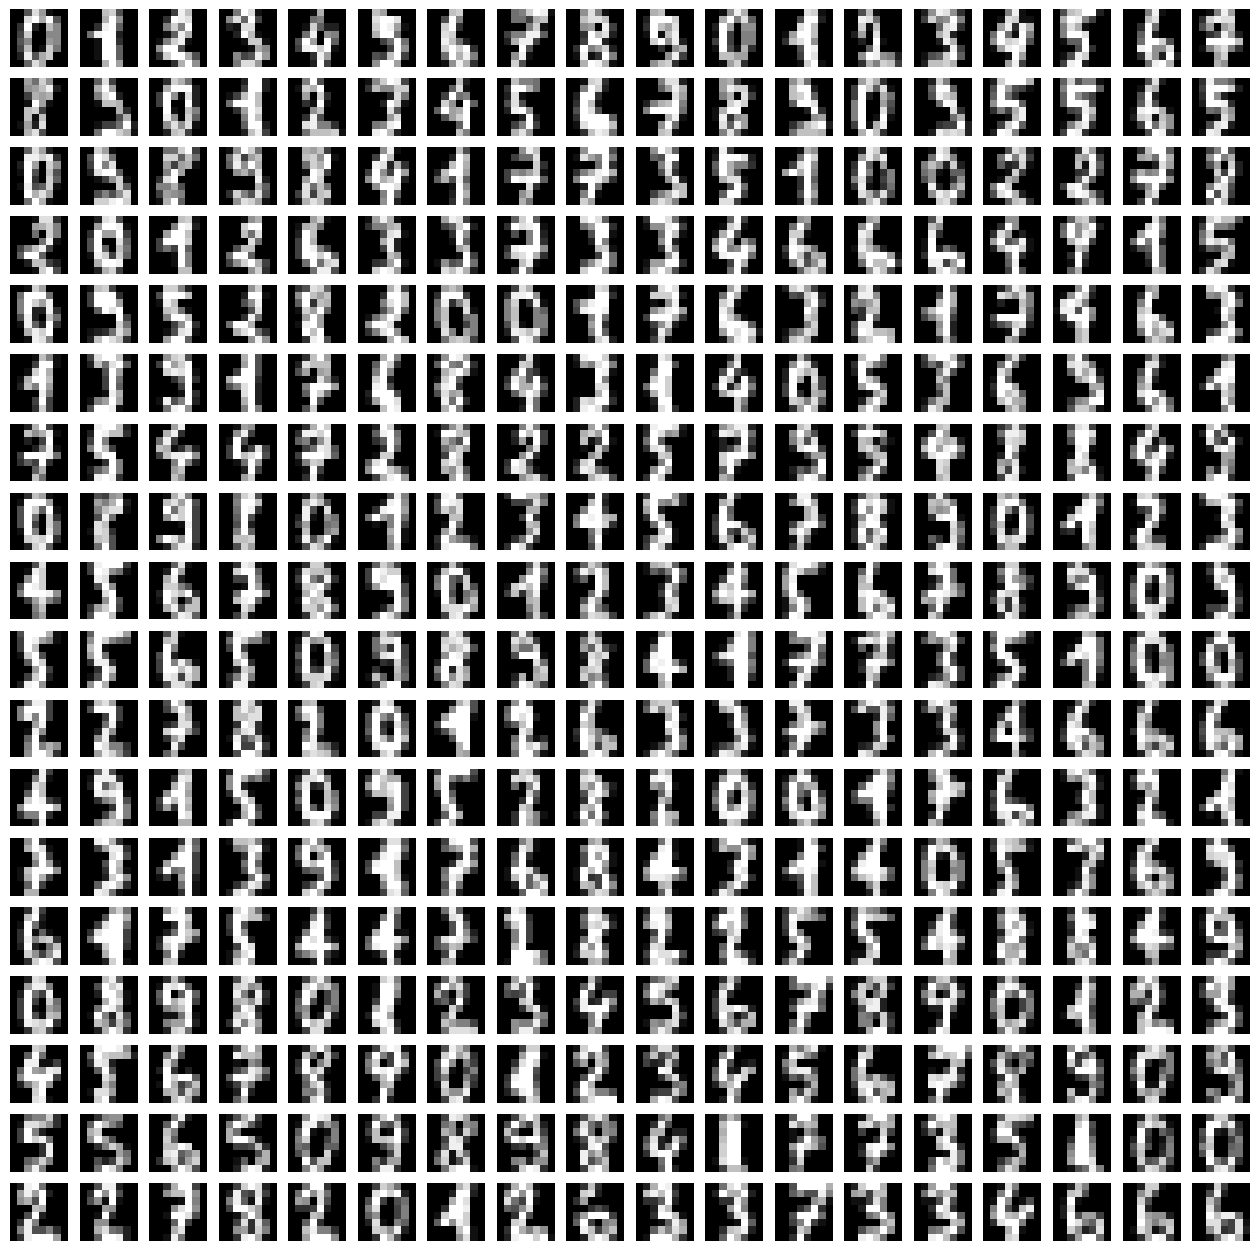

In [6]:
print("MNIST examples from dataset")
plot_images(X_data)
plt.show()

## Convolutional Neural Network (CNN)

Nun trainieren wir ein CNN auf diesen Daten.

Als erstes teilen wir die Daten in `Train Set` und `Validation Set` auf.

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, random_state=42)

Das hier verwendete Neurale Netzwerk hat 4 Layers:
* Einen Input Layer
* Zwei Hidden Layers
* Einen Output Layer

Der Input Layer ist ein 8 Pixel mal 8 Pixel Bild bzw. 2D-Array. Als erstes `Reshapen` wir diesen 2D-Array mit 8 mal 8 Dimensionen zu einem 1D-Array mit 64 Dimensionen, weil das Feedforward Neural Network erwartet die Inputs als 1D-Array.
Dann kommt das eigentliche Netzwerk.
Der Input Layer ist dieser 1D-Array mit 64 Neuronen.
Dann kommt ein Hidden Layer (`hidden_layer_1`) mit 128 Neuronen.
Dann kommt ein Hidden Layer (`hidden_layer_2`) mit 64 Neuronen.
Dann kommt der Output Layer (`output_layer`) mit 10 Neuronen (weil wir 10 Klassen haben).
Die Hidden Layers haben alle die Aktivierungsfunktion `ReLU`.
Der Output Layer hat die Aktivierungsfunktion `softmax` (hier `linear` mit  `losses.SparseCategoricalCrossentropy(from_logits=True)` als Kostenfunktion, was indirekt dem Softmax entspricht).
Das Neurale Netzwerk wird mit Batch Gradient Descent (`sgd`) trainiert und nach der Maximum Liklihood Kostenfunktion optimiert (`SparseCategoricalCrossentropy`). Zudem wollen wir die Performanz vom Modell mit der Kostenfunktion `accuracy` messen.

`nn.summary()` gibt uns Informationen zur Architektur vom Netzwerk. Wir finden unsere Layers wieder und sehen wie viele Parameter (Verbindungen) pro Layer tatsächlich vorhanden sind.

In [8]:
from tensorflow.keras import Sequential, layers, activations, losses
from tensorflow.keras.regularizers import L2

nn = Sequential([
    # 1. Input
    layers.InputLayer(input_shape=(8, 8), name='input_layer'),
    # CNNs brauchen eine Channel-Dimension: Aus (8,8) wird (8,8,1)
    layers.Reshape(target_shape=(8, 8, 1), name='reshape_channel_layer'),

    # 2. Feature Extraction (Faltung & Pooling)
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation=activations.relu, name='conv_layer_1'),
    layers.MaxPooling2D(pool_size=(2, 2), name='pooling_layer_1'), # (8, 8) -> (4, 4)
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation=activations.relu, name='conv_layer_2'),
    layers.MaxPooling2D(pool_size=(2, 2), name='pooling_layer_2'), # (4, 4) -> (2, 2)
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation=activations.relu, name='conv_layer_3'),
    layers.MaxPooling2D(pool_size=(2, 2), name='pooling_layer_3'), # (2, 2) -> (1, 1)

    # 3. Klassifikation (Übergang zu klassischem Netz)
    layers.Flatten(name='flatten_layer'),
    layers.Dense(10, activation=activations.linear, name='output_layer'),
])

nn.compile(
    optimizer='sgd',
    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(nn.summary())

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_channel_layer (Reshape) │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer_1 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer_3 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,962 (367.04 KB)

 Trainable params: 93,962 (367.04 KB)

 Non-trainable params: 0 (0.00 B)

None


Bis jetzt haben wir nur das Netzwerk aufgebaut.

Nun fitten wir es noch mit den Daten. Dazu müssen wir die `batch_size` für Batch Gradient Descent angeben und wie oft es über die gesamten Daten iterieren soll (`epochs`).
Zudem geben wir hier die Validation Daten an. Dann reportet und Tensorflow während dem Training die Performanz auf dem `Validation Set`.
Nach dem Training visualisieren wir die `Learning Curve`, die uns zeigt, wie sich die `accuracy` vom Netzwerk über die Epochen entwickelt.

In [9]:
history = nn.fit(X_train, y_train, batch_size=128, epochs=50, validation_data=(X_val, y_val))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3111 - loss: 2.1406 - val_accuracy: 0.5911 - val_loss: 1.7892
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6600 - loss: 1.6165 - val_accuracy: 0.7622 - val_loss: 1.3870
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6414 - loss: 1.3678 - val_accuracy: 0.5378 - val_loss: 1.3680
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7751 - loss: 1.0163 - val_accuracy: 0.8778 - val_loss: 0.8079
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7624 - loss: 0.9217 - val_accuracy: 0.8844 - val_loss: 0.6505
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8337 - loss: 0.6721 - val_accuracy: 0.7822 - val_loss: 0.8798
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8782 - loss: 0.5581 - val_accuracy: 0.9244 - val_loss: 0.4043
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9131 - loss: 0.4010 - val_accuracy: 0.7867 - val_los

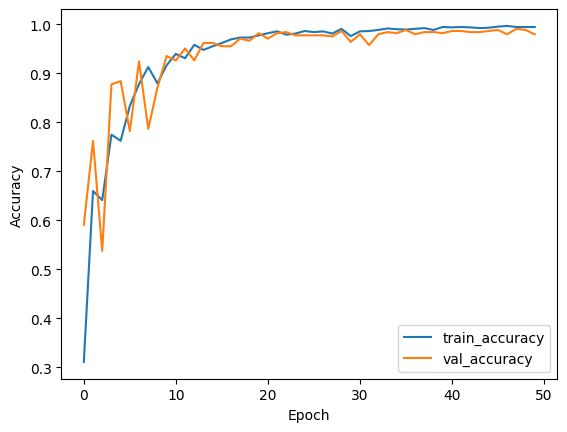

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
0.98


In [10]:
plot_history(history)

y_val_hat_prob = nn.predict(X_val)
y_val_hat = np.argmax(y_val_hat_prob, axis=1)

print(accuracy_score(y_val_hat, y_val))